In [6]:
import cv2
def sketch(img):
    blur = cv2.GaussianBlur([img],(3,3),1)
    canny_edges = cv2.Canny(blur,10,70)
    ret, mask = cv2.threshold(canny_edges,70,255,cv2.THRESH_BINARY_INV)
    return ret

In [7]:
img = cv2.imread("leena.jpg")
imgn = sketch(img)
cv2.imshow("img",img)
cv2.waitKey(0)
cv2.destroyAllWindows()

error: OpenCV(4.13.0) :-1: error: (-5:Bad argument) in function 'GaussianBlur'
> Overload resolution failed:
>  - src is not a numpy array, neither a scalar
>  - Expected Ptr<cv::UMat> for argument 'src'


In [1]:
import cv2
import numpy as np

cap = cv2.VideoCapture(0)

while True:
    # It contains a boolean indicating if it was sucessful (ret)
    # It also contains the images collected from the webcam (frame)
    ret, frame = cap.read()

    cv2.imshow("video",frame)

    if cv2.waitKey(1)==13: #13 is enter key
        break
cap.release()
cv2.destroyAllWindows()

## opening video files

In [9]:
cap = cv2.VideoCapture("sample_vid.mp4")

while cap.isOpened():
    ret, framess = cap.read()

    ## if frames are read correctly ret is true

    if not ret:
        print("steam stopped")
        break
    cv2.imshow("video",framess)

    if cv2.waitKey(1) == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

## cap.get(id)

is a method where id is a number from 0 to 18.Each number denotes a property of the video

In [11]:
cap = cv2.VideoCapture("sample_vid.mp4")
for i in range(0,10):
    print(cap.get(i))

0.0
0.0
1.1111111111111112e-05
600.0
480.0
25.0
875967080.0
5850.0
0.0
0.0


## Saving video 
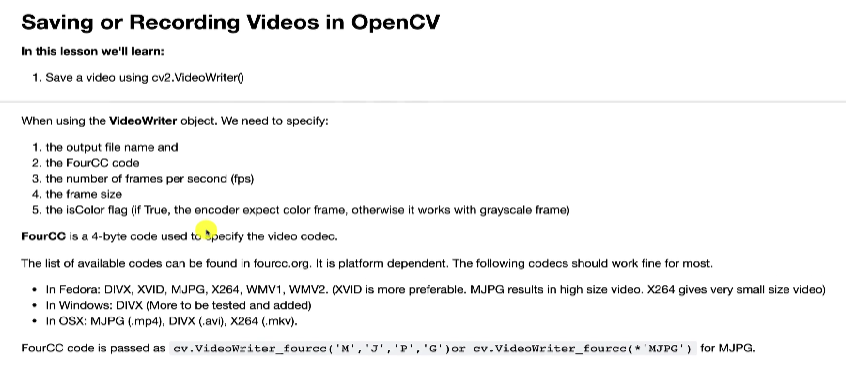

In [12]:
cap = cv2.VideoCapture("sample_vid.mp4")

w = int(cap.get(3))
h = int(cap.get(4))

out = cv2.VideoWriter("song.avi",cv2.VideoWriter_fourcc('M','J','P','G'),30,(w,h),False)

while(1):

    ret, frame = cap.read()
    if ret == True:
        gray = cv2.cvtColor(frame,cv2.COLOR_BGR2GRAY)
        out.write(gray)
    else:
        break
        print("converted to gray scale")

cap.release()
out.release()
cv2.destroyAllWindows()

## Streams and IP videos
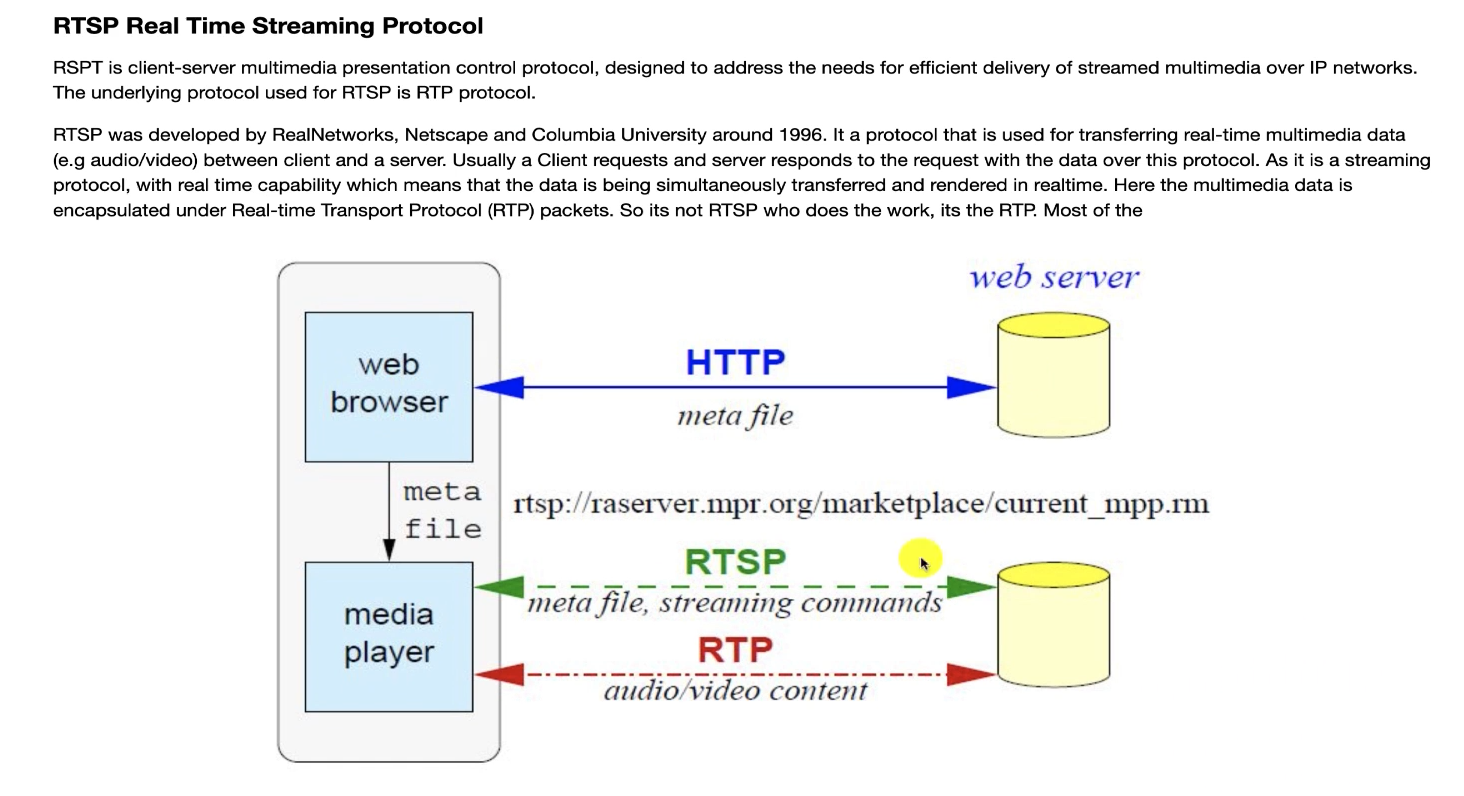

In [ ]:
import cv2

cap = cv2.VideoCapture("rtsp://wowzaec2demo.streamlock.net/vod/mp4:BigBuckBunny_115k.mov")

while(1):
    ret, frame = cap.read()

    cv2.imshow("RTSP stream", frame)

    if cv2.waitKey(1) == 13: #enter key
        break

cap.release()
cv2.destroyAllWindows()



## auto reconnect to video stream on failure

## Caputing video through screen shot

## importing videos from youtube

In [2]:
import pafy
import cv2

url = "https://youtu.be/EFEmTsfFL5A"

Video = pafy.new(url)

best = Video.getbest(preftype="mp4")

capture = cv2.VideoCapture()
capture.open(best.url)

while(True):
    ret, frame = capture.read()
    if ret == True:
        cv2.imshow('src',frame)

    if cv2.waitKey(1) == 13:
        ## enter key
        break
capture.release()
cv2.destroyAllWindows()


ImportError: pafy: youtube-dl not found; you can use the internal backend by setting the environmental variable PAFY_BACKEND to "internal". It is not enabled by default because it is not as well maintained as the youtube-dl backend.